In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import geopandas as gpd
from shapely.geometry import Point
pd.set_option('display.max_columns', 500)
import contextily as ctx

In [5]:
df = pd.read_csv('../data/data1.csv', sep = ';')

In [2]:
powiaty = gpd.read_file('../data/powiaty.shp')

In [3]:
dzielnice = gpd.read_file('../data/dzielnice_Warszawy.shp')

In [6]:
geometry = [Point(lon, lat) for lon, lat in zip(df['lon'], df['lat'])]
gdf = gpd.GeoDataFrame(df, geometry=geometry, crs="EPSG:4326")

In [7]:
powiaty = powiaty.to_crs(gdf.crs)
dzielnice = dzielnice.to_crs(gdf.crs)

In [8]:
spatial_join_powiaty = gpd.sjoin(powiaty, gdf, how='inner', op='contains')

C:\Users\olekw\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\IPython\core\interactiveshell.py:3448: FutureWarning: The `op` parameter is deprecated and will be removed in a future release. Please use the `predicate` parameter instead.
  if await self.run_code(code, result, async_=asy):


In [9]:
powiaty_maz = spatial_join_powiaty[['JPT_NAZWA_', 'geometry']]


In [10]:
powiaty_maz

,JPT_NAZWA_,geometry
2,powiat ostrołęcki,"POLYGON ((21.20011 53.39916, 21.20178 53.40052..."
2,powiat ostrołęcki,"POLYGON ((21.20011 53.39916, 21.20178 53.40052..."
2,powiat ostrołęcki,"POLYGON ((21.20011 53.39916, 21.20178 53.40052..."
2,powiat ostrołęcki,"POLYGON ((21.20011 53.39916, 21.20178 53.40052..."
2,powiat ostrołęcki,"POLYGON ((21.20011 53.39916, 21.20178 53.40052..."
...,...,...
368,powiat Płock,"POLYGON ((19.69555 52.47374, 19.69474 52.47403..."
368,powiat Płock,"POLYGON ((19.69555 52.47374, 19.69474 52.47403..."
368,powiat Płock,"POLYGON ((19.69555 52.47374, 19.69474 52.47403..."
368,powiat Płock,"POLYGON ((19.69555 52.47374, 19.69474 52.47403..."


In [11]:
powiaty_maz = powiaty_maz.drop_duplicates(subset='JPT_NAZWA_')

<Axes: >

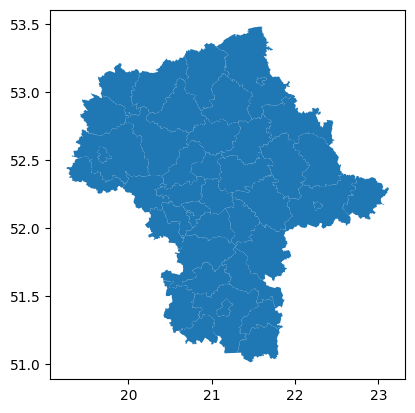

In [12]:
powiaty_maz.plot()

In [13]:
warsaw = gpd.sjoin(gdf, dzielnice,  how='inner', op='within')

C:\Users\olekw\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\IPython\core\interactiveshell.py:3448: FutureWarning: The `op` parameter is deprecated and will be removed in a future release. Please use the `predicate` parameter instead.
  if await self.run_code(code, result, async_=asy):


In [14]:
kod_tech = pd.read_csv("../data/lista high tech.csv", sep = ";")

In [15]:
pop_point = pd.read_csv("../data/points_popul_maz.csv", sep = ",")

In [16]:
gdf_ht = gdf[gdf['if_hightech'] == 1]

In [17]:
import pickle

with open('../data/gdf_ht.pickle', 'wb') as file:
    pickle.dump(gdf_ht, file)

In [18]:
import pickle

with open('../data/gdf.pickle', 'wb') as file:
    pickle.dump(gdf, file)

In [19]:
with open('../data/warsaw.pickle', 'wb') as file:
    pickle.dump(warsaw, file)

In [20]:
with open('../data/dzielnice.pickle', 'wb') as file:
    pickle.dump(dzielnice, file)

In [21]:
with open('../data/powiaty_maz.pickle', 'wb') as file:
    pickle.dump(powiaty_maz, file)

# County data vis

In [16]:
powiaty_maz

,JPT_NAZWA_,geometry
2,powiat ostrołęcki,"POLYGON ((21.20011 53.39916, 21.20178 53.40052..."
9,powiat sochaczewski,"POLYGON ((20.47832 52.22417, 20.47817 52.22403..."
10,powiat warszawski zachodni,"POLYGON ((20.47832 52.22417, 20.47845 52.22434..."
60,powiat łosicki,"POLYGON ((22.72381 52.28039, 22.72379 52.28043..."
61,powiat sierpecki,"POLYGON ((19.50876 52.86784, 19.50873 52.86795..."
62,powiat gostyniński,"POLYGON ((19.61602 52.28815, 19.61603 52.28819..."
63,powiat grodziski,"POLYGON ((20.70416 52.13281, 20.70421 52.13281..."
70,powiat Radom,"POLYGON ((21.19499 51.34862, 21.19473 51.34864..."
71,powiat żyrardowski,"POLYGON ((20.25310 52.05533, 20.25234 52.05558..."
73,powiat Siedlce,"POLYGON ((22.24185 52.12755, 22.24135 52.12845..."


<Axes: >

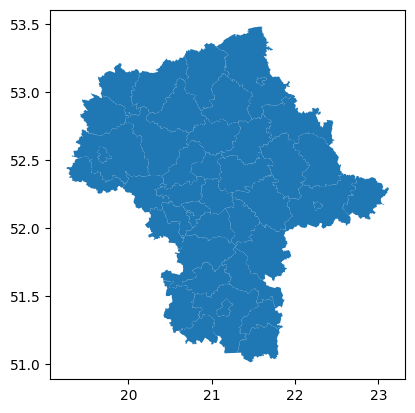

In [17]:
powiaty_maz.plot()

In [33]:
county_data = pd.read_excel('../data/_countydata.xlsx', header=1)
county_data = county_data.drop(columns = 'Code')
county_data = county_data.drop(columns = 'POWIAT')
county_data

,Name,exp_per1,inc_per1,UE_fin,inv_per1,museums,mus_visitors,cinemas_spaces,pop_per_1lib,book_rentals_per1,crime,crime_per1k,apts_bought,unemployment,work_accidents,work_accidents_per1k,students,graduates,avg_salary,avg_salary_to_PL,hipermarkets,supermarkets,depos,stores,all_stores,apts_available,buses,schools,Unnamed: 30,Unnamed: 31,Unnamed: 32,Unnamed: 33
0,MAZOWIECKIE,866.61,859.19,1.170926e+08,5256,115,12578.1,119,4846,16.0,142841,26.99,17251,10.7,11.87,5.47,312033,85053,4637.58,123.9,73,608,10,46,737,2112511,15085,3755,314,687,1745,1009
1,powiat białobrzeski,1006.68,970.87,5.996404e+06,883,0,0.0,0,3376,17.7,748,22.13,0,17.0,0.02,3.49,0,0,3355.88,89.6,0,2,0,0,2,11509,97,28,0,1,19,8
2,powiat ciechanowski,929.16,937.63,4.047298e+06,4872,3,2921.8,236,4562,23.4,2531,27.72,122,17.3,0.13,5.15,1955,714,3385.81,90.4,0,10,1,1,12,30163,299,89,15,20,32,22
3,powiat garwoliński,929.12,889.09,3.796153e+06,1877,1,129.0,431,3745,16.5,2193,20.21,8,14.5,0.09,3.53,191,89,3277.05,87.5,0,14,0,0,14,33511,351,117,1,11,67,38
4,powiat gostyniński,992.63,1016.06,1.309765e+06,1091,0,0.0,120,3108,17.1,695,14.87,35,23.2,0.07,6.66,0,0,2925.45,78.1,0,7,0,0,7,15798,121,37,0,8,17,12
5,powiat grodziski,814.44,811.79,6.509519e+05,4385,1,422.0,233,5470,14.6,2055,23.64,0,7.8,0.13,4.30,978,427,3854.84,103.0,0,9,0,0,9,32651,344,56,4,11,26,15
6,powiat grójecki,896.62,880.54,4.136573e+06,3006,2,153.2,363,4932,15.9,2800,28.42,0,8.6,0.10,4.29,60,20,3589.76,95.9,1,9,0,0,10,35085,337,89,7,16,49,17
7,powiat kozienicki,1047.61,930.29,3.461797e+06,3985,2,1486.5,0,3278,14.8,1707,27.37,127,19.1,0.08,5.25,0,0,4239.66,113.2,0,5,0,0,5,21415,223,55,4,8,29,14
8,powiat legionowski,734.25,731.96,2.063938e+06,2995,1,655.7,2198,6464,20.8,2938,26.87,247,14.7,0.09,3.34,0,0,3600.74,96.2,3,11,0,2,16,41107,349,51,2,6,26,17
9,powiat lipski,1289.51,1215.90,2.599095e+06,411,0,0.0,0,2991,24.5,734,20.32,0,17.0,0.01,2.27,0,0,3098.37,82.7,0,3,0,0,3,13036,58,40,3,6,20,11


In [34]:
# Merge the DataFrames on the county names
merged_data = pd.merge(powiaty_maz, county_data, left_on='JPT_NAZWA_', right_on='Name', how='left')

# Ensure the resulting DataFrame only contains data for counties in powiaty_maz
filtered_data = merged_data[merged_data['JPT_NAZWA_'].notnull()]

# Display the first few rows of the filtered DataFrame
filtered_data.head()

,JPT_NAZWA_,geometry,Name,exp_per1,inc_per1,UE_fin,inv_per1,museums,mus_visitors,cinemas_spaces,pop_per_1lib,book_rentals_per1,crime,crime_per1k,apts_bought,unemployment,work_accidents,work_accidents_per1k,students,graduates,avg_salary,avg_salary_to_PL,hipermarkets,supermarkets,depos,stores,all_stores,apts_available,buses,schools,Unnamed: 30,Unnamed: 31,Unnamed: 32,Unnamed: 33
0,powiat ostrołęcki,"POLYGON ((21.20011 53.39916, 21.20178 53.40052...",powiat ostrołęcki,779.76,738.37,1306421.82,794,1,843.7,0,2928,13.7,3815,43.50,4,18.7,0.07,6.28,0,0,3213.82,85.8,0,2,0,1,3,23404,158,113,5,11,70,27
1,powiat sochaczewski,"POLYGON ((20.47832 52.22417, 20.47817 52.22403...",powiat sochaczewski,889.64,901.49,4100856.33,2754,4,24482.6,312,4055,19.3,2478,29.11,58,11.5,0.20,7.76,382,99,3740.62,99.9,2,4,0,2,8,28578,161,69,3,14,32,20
2,powiat warszawski zachodni,"POLYGON ((20.47832 52.22417, 20.47845 52.22434...",powiat warszawski zachodni,1002.97,1028.50,2631591.87,4891,2,1290.1,457,6090,26.7,2621,24.07,362,6.6,0.26,5.49,0,0,4050.54,108.2,2,16,0,1,19,40864,442,49,1,6,25,17
3,powiat łosicki,"POLYGON ((22.72381 52.28039, 22.72379 52.28043...",powiat łosicki,1064.74,1062.77,924364.33,1104,0,0.0,126,2485,33.8,603,18.60,4,12.4,0.04,5.94,0,0,3025.24,80.8,0,3,0,0,3,11237,101,37,0,3,23,11
4,powiat sierpecki,"POLYGON ((19.50876 52.86784, 19.50873 52.86795...",powiat sierpecki,1019.62,954.17,771908.09,1262,1,9699.9,180,2818,18.5,1665,31.04,27,25.0,0.07,7.04,0,0,3043.46,81.3,0,5,0,0,5,16364,220,47,3,9,23,12


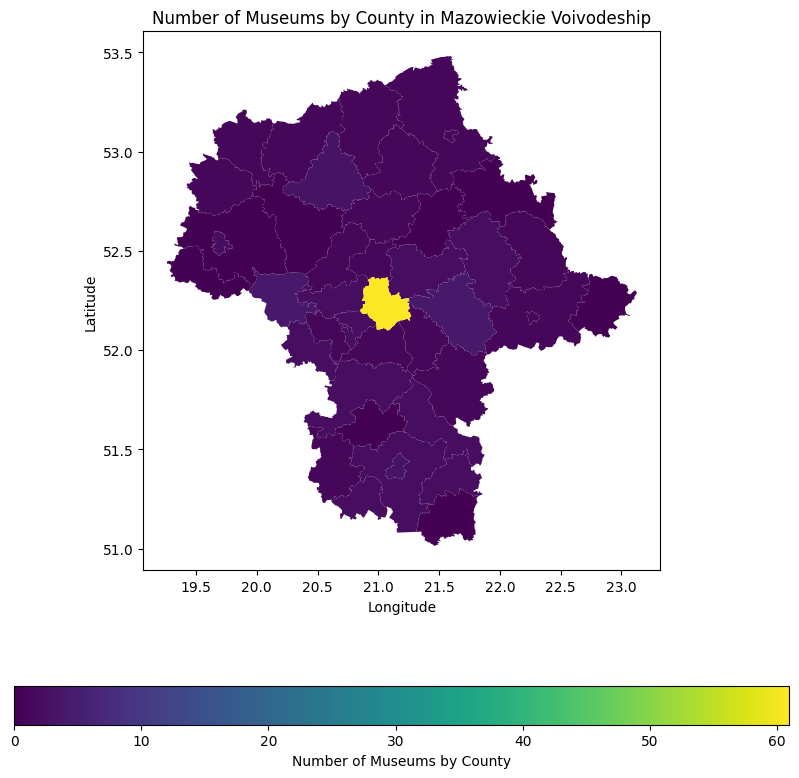

In [36]:
# Plot the county polygons
fig, ax = plt.subplots(1, 1, figsize=(10, 10))
merged_data.plot(column='museums', ax=ax, legend=True,
                legend_kwds={'label': "Number of Museums by County",
                             'orientation': "horizontal"})

# Optionally, you can add titles and labels
ax.set_title('Number of Museums by County in Mazowieckie Voivodeship')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')

# Show the plot
plt.show()

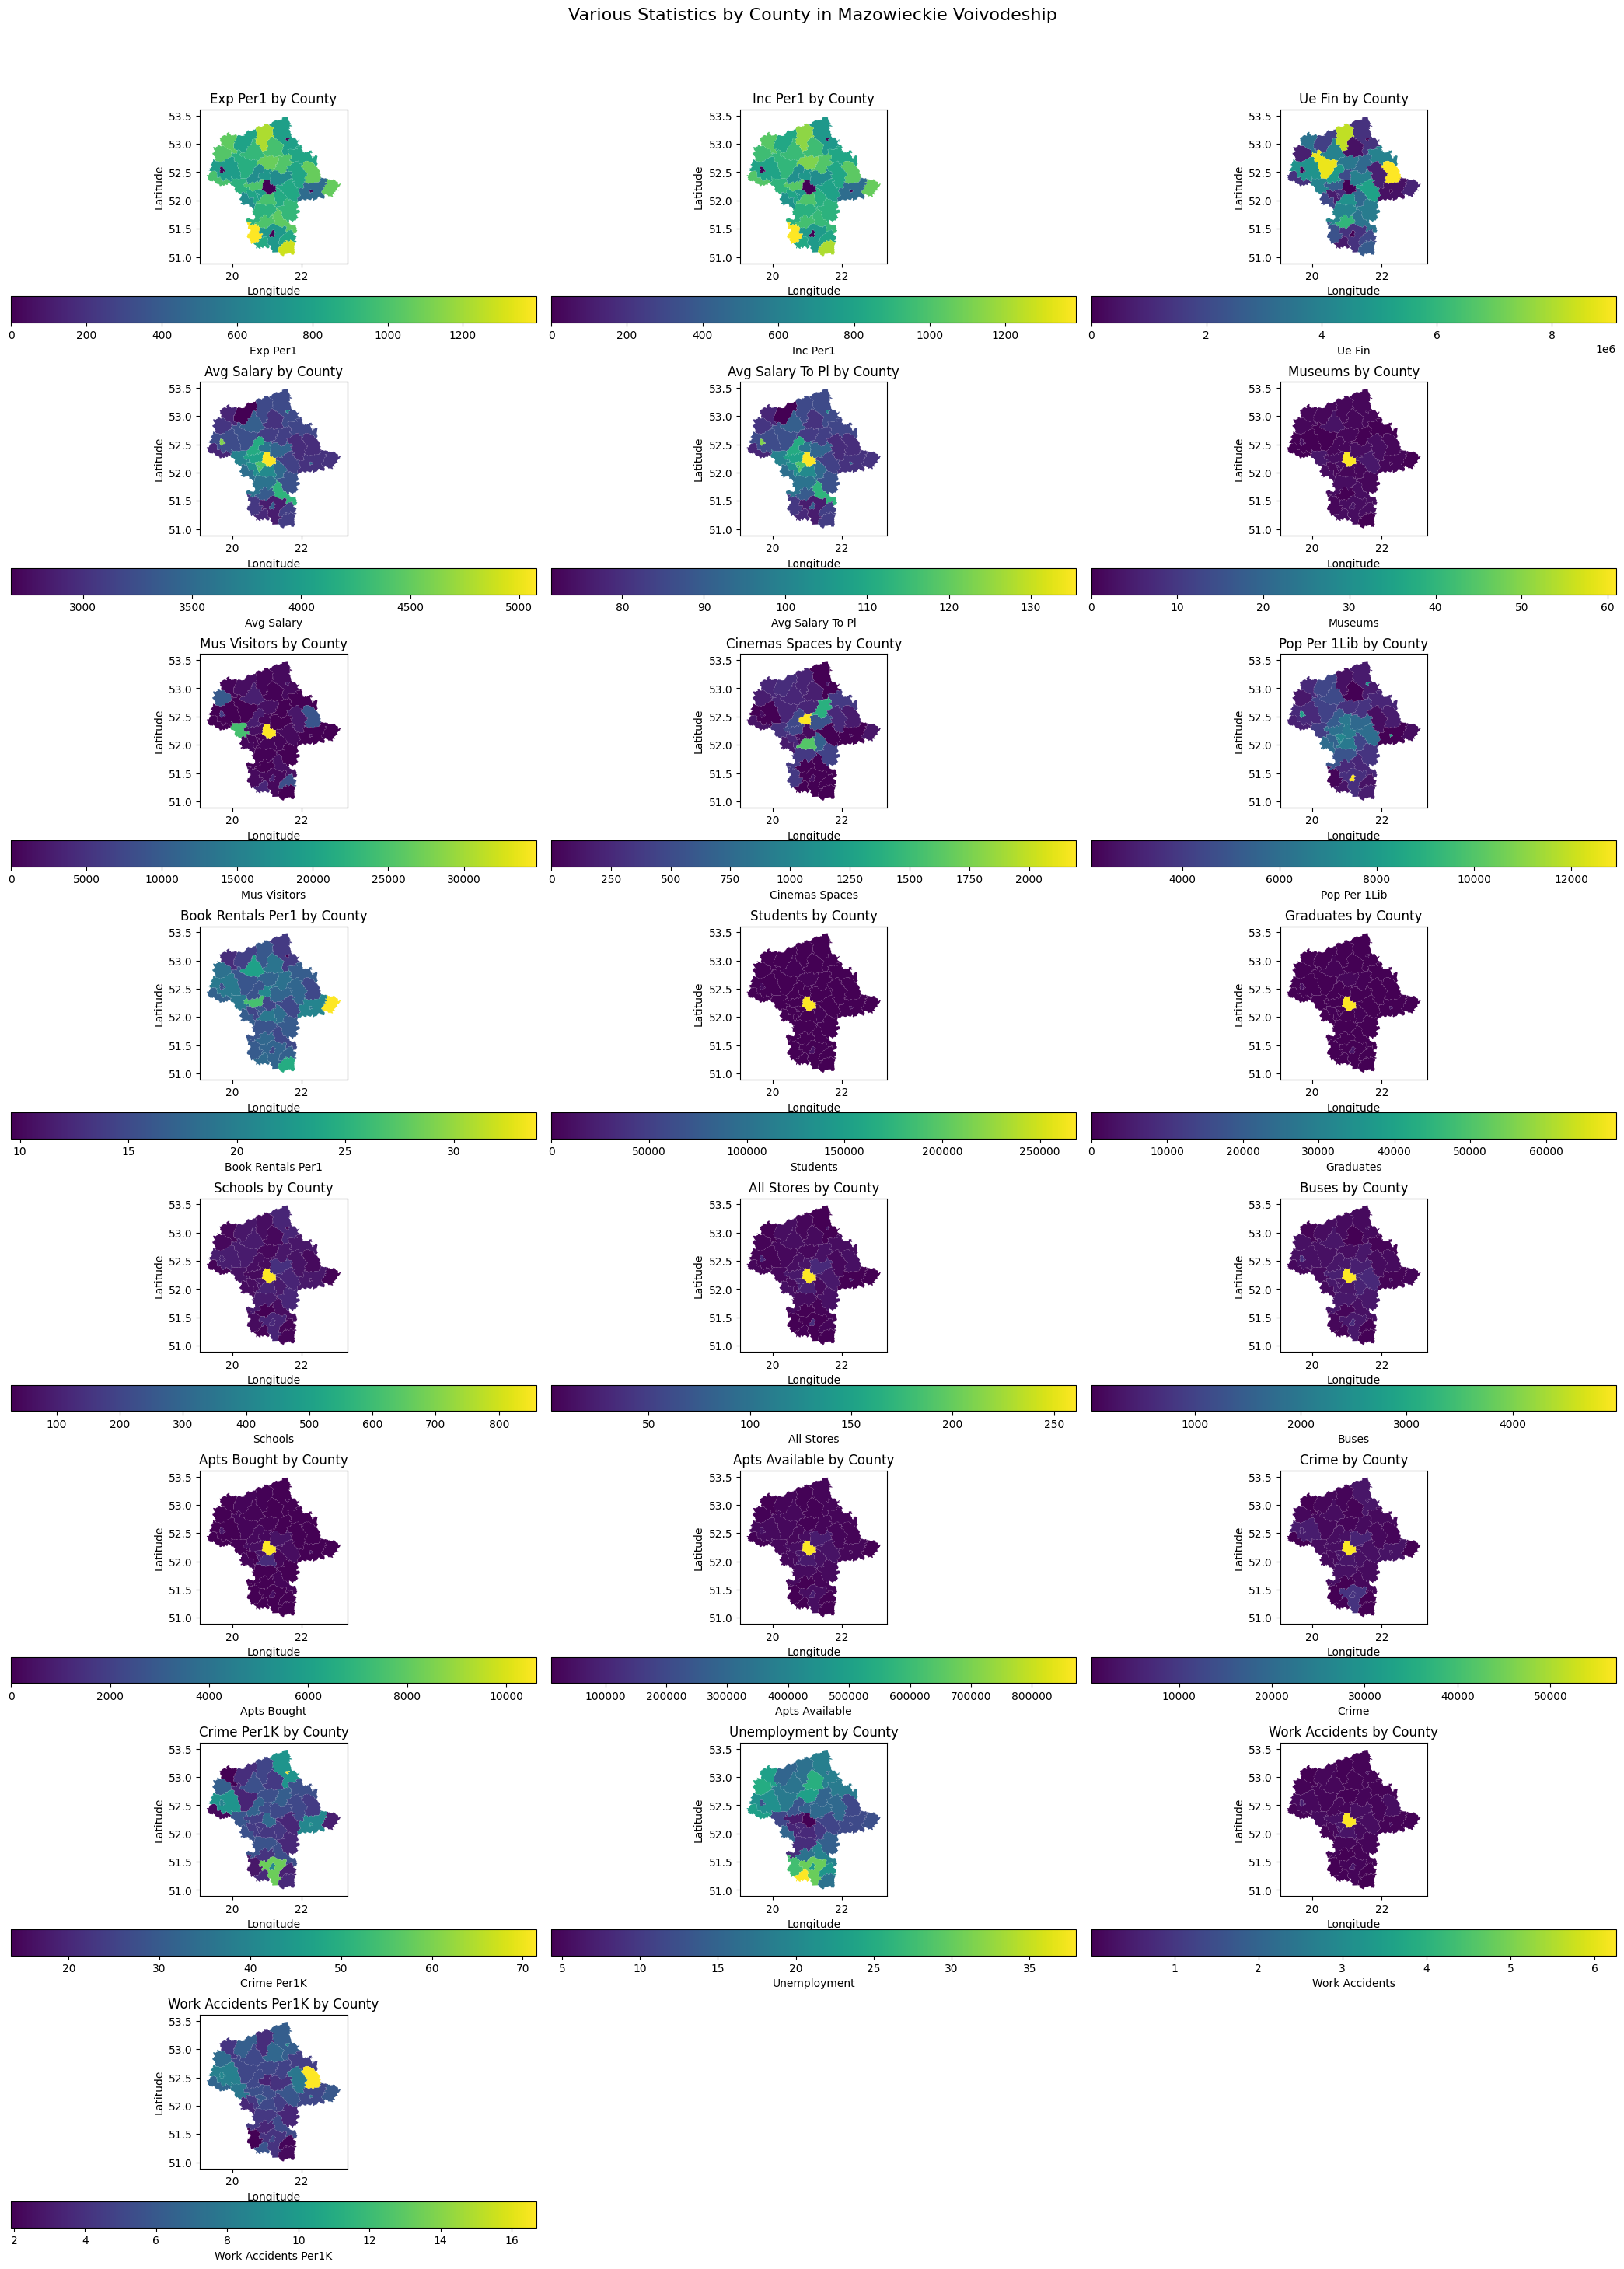

In [38]:
import matplotlib.pyplot as plt

# List of columns to plot
columns_to_plot = [
    'exp_per1', 'inc_per1', 'UE_fin', 'avg_salary', 'avg_salary_to_PL', 'museums', 
    'mus_visitors', 'cinemas_spaces', 'pop_per_1lib', 'book_rentals_per1', 'students', 
    'graduates', 'schools', 'all_stores', 'buses', 'apts_bought', 'apts_available', 
    'crime', 'crime_per1k', 'unemployment', 'work_accidents', 'work_accidents_per1k'
]

# Calculate the number of rows and columns needed for the grid
n_cols = 3
n_rows = (len(columns_to_plot) + n_cols - 1) // n_cols

# Create a figure with subplots
fig, axes = plt.subplots(n_rows, n_cols, figsize=(21, 29.7))  # A4 size in inches (21cm x 29.7cm)
fig.suptitle('Various Statistics by County in Mazowieckie Voivodeship', fontsize=16)

# Flatten the axes array for easy iteration
axes = axes.flatten()

# Plot each column
for i, column in enumerate(columns_to_plot):
    ax = axes[i]
    merged_data.plot(column=column, ax=ax, legend=True,
                     legend_kwds={'label': f"{column.replace('_', ' ').title()}",
                                  'orientation': "horizontal"})
    
    ax.set_title(f'{column.replace("_", " ").title()} by County')
    ax.set_xlabel('Longitude')
    ax.set_ylabel('Latitude')

# Hide any empty subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

# Adjust layout and show plot
plt.tight_layout(rect=[0, 0, 1, 0.96])  # Adjust the layout to make room for the title
plt.show()

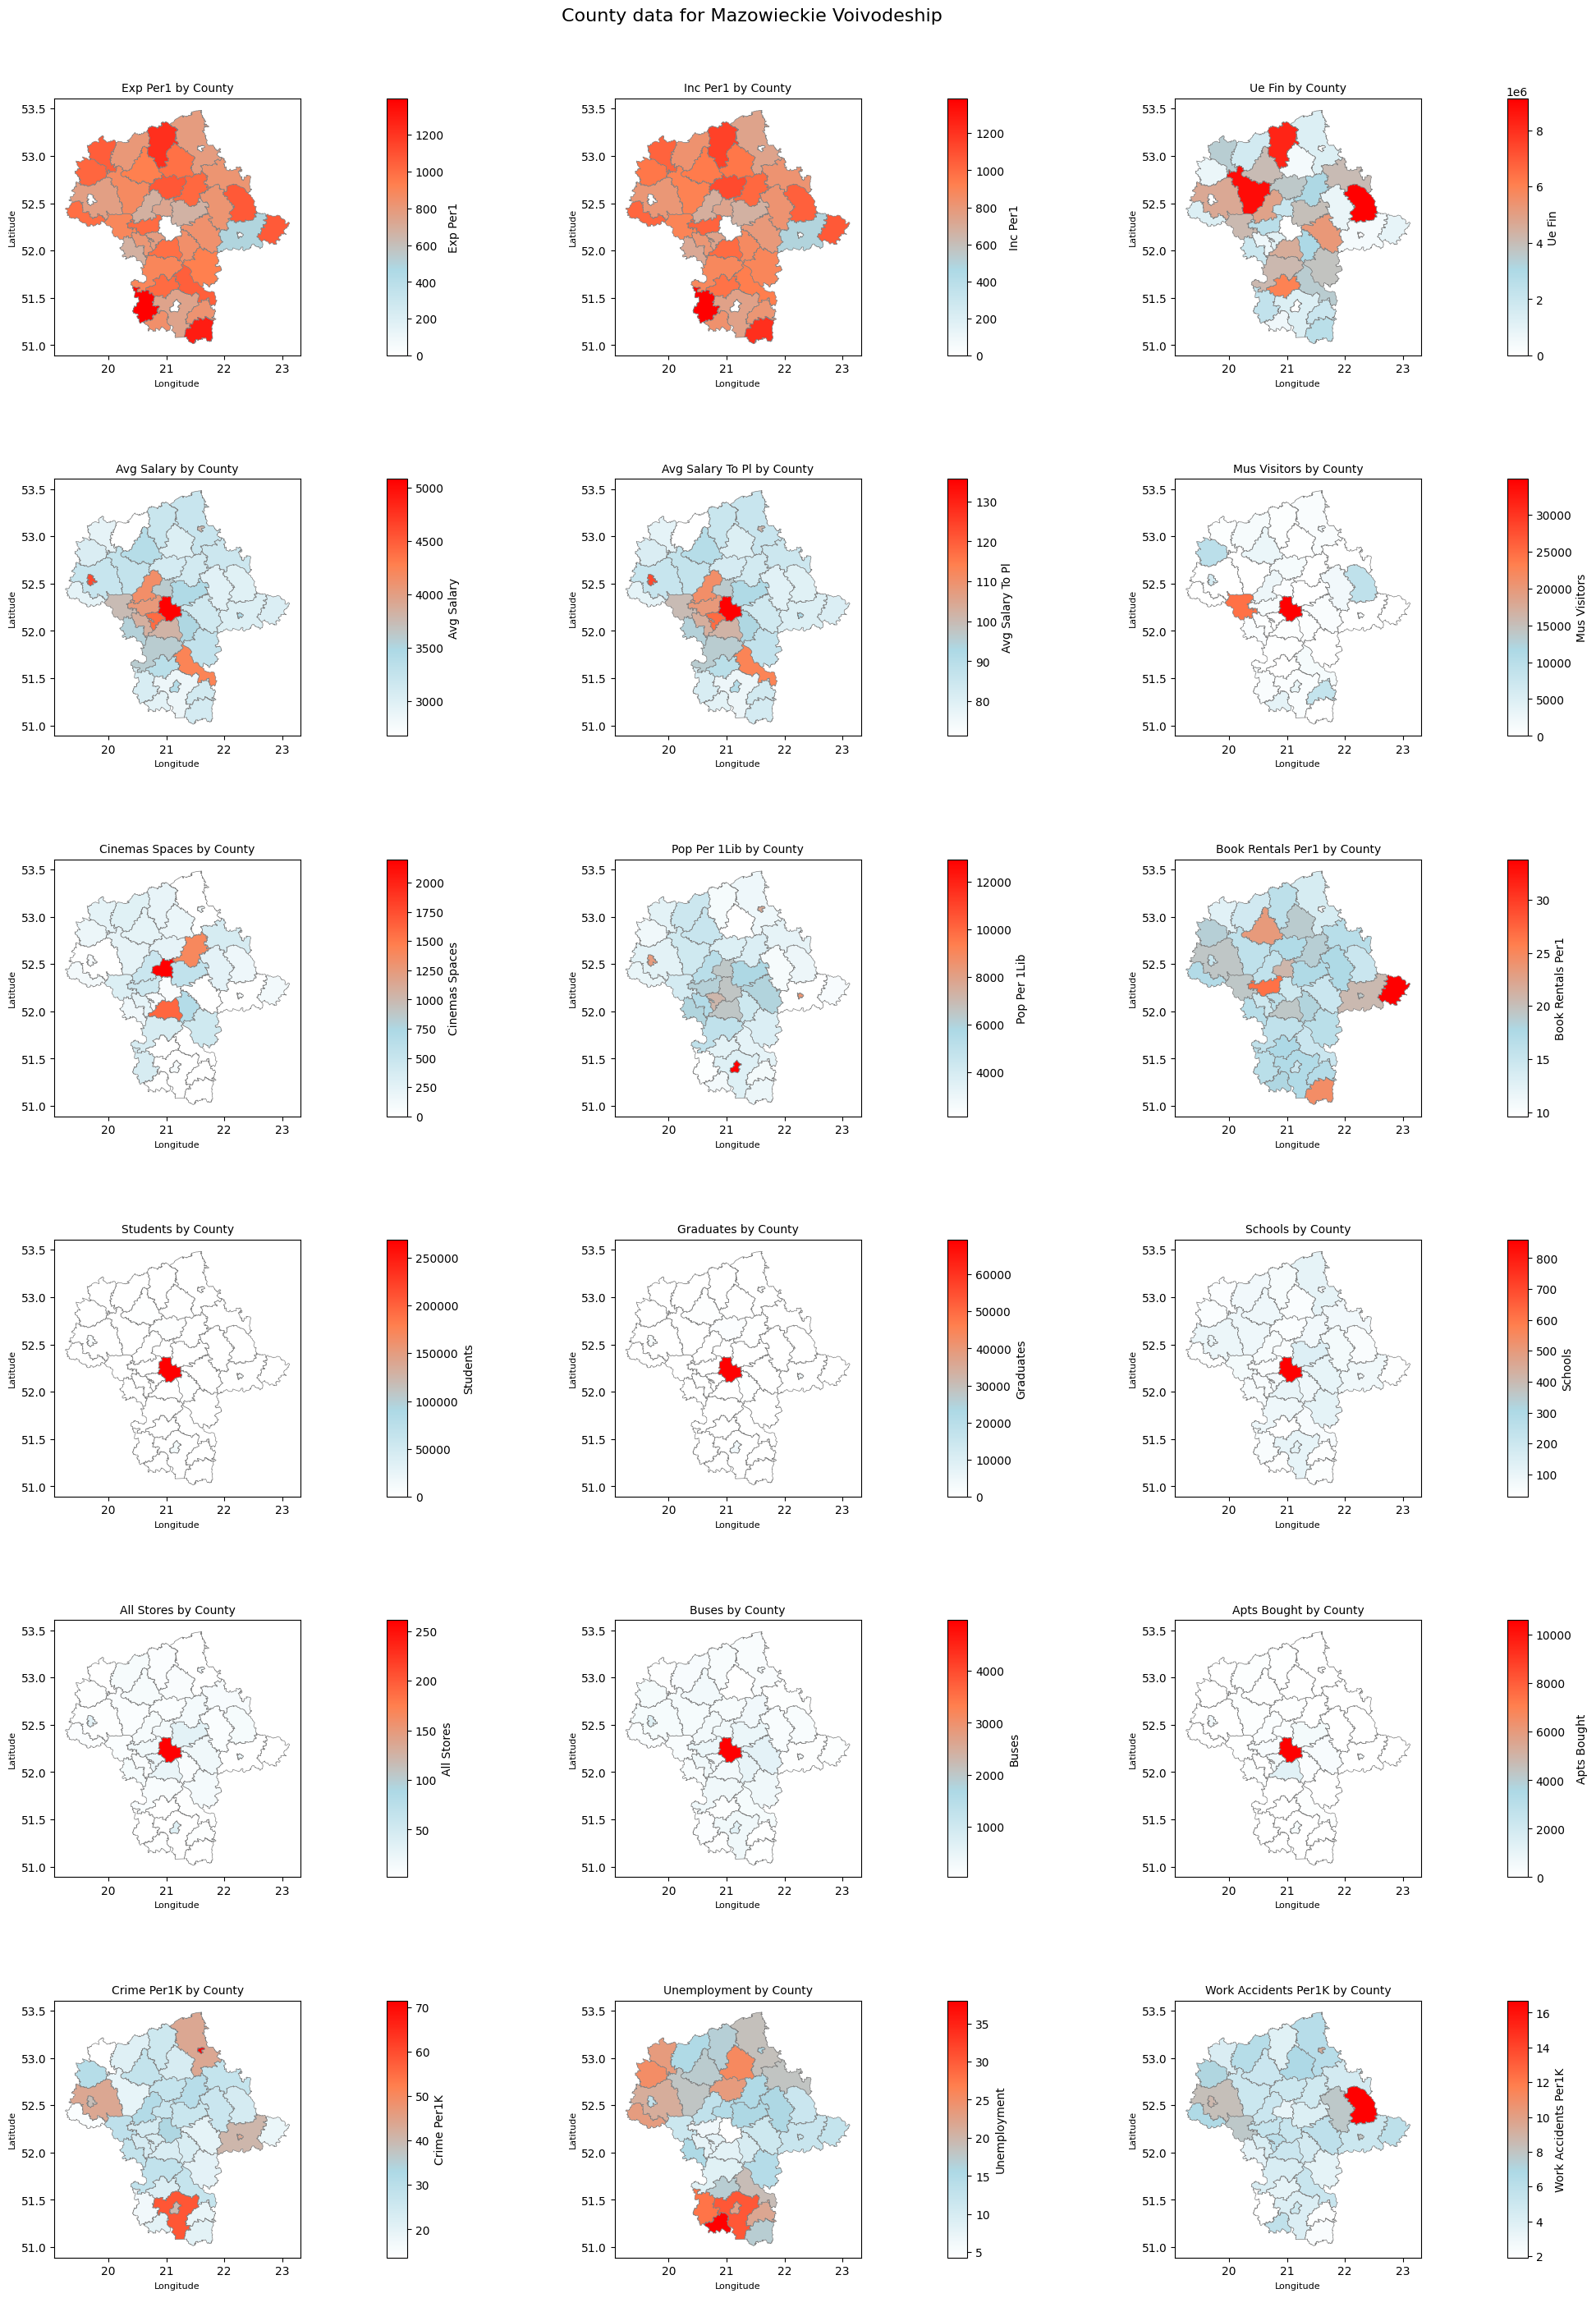

In [49]:
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import make_axes_locatable
from matplotlib.colors import LinearSegmentedColormap
import numpy as np
import geopandas as gpd
import pandas as pd

# Color palette
colors = [(1, 1, 1), (0.68, 0.85, 0.9), (1, 0.5, 0.31), (1, 0, 0)]  
# White, Lightblue, Coral, Red

cmap = LinearSegmentedColormap.from_list("custom_colormap", colors)

# List of columns to plot
columns_to_plot = [
    'exp_per1', 'inc_per1', 'UE_fin', 'avg_salary', 'avg_salary_to_PL', 'mus_visitors', 'cinemas_spaces', 'pop_per_1lib', 'book_rentals_per1', 'students', 'graduates', 'schools', 'all_stores', 'buses', 'apts_bought', 'crime_per1k', 'unemployment', 'work_accidents_per1k'
]

n_cols = 3
n_rows = (len(columns_to_plot) + n_cols - 1) // n_cols

# Subplots
fig, axes = plt.subplots(n_rows, n_cols, figsize=(21, 29.7))  # A4
fig.suptitle('County data for Mazowieckie Voivodeship', fontsize=16)

axes = axes.flatten()

# Plot each column
for i, column in enumerate(columns_to_plot):
    ax = axes[i]

    im = merged_data.plot(column=column, ax=ax, legend=False, cmap=cmap, edgecolor='grey', linewidth=0.5)
    
    # Create colorbar
    divider = make_axes_locatable(ax)
    cax = divider.append_axes("right", size="5%", pad=0.1)

    vmin = merged_data[column].min()
    vmax = merged_data[column].max()
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(vmin=vmin, vmax=vmax))
    sm.set_array([])
    cbar = fig.colorbar(sm, cax=cax)
    cbar.set_label(f"{column.replace('_', ' ').title()}", fontsize=10)
    
    ax.set_title(f'{column.replace("_", " ").title()} by County', fontsize=10)
    ax.set_xlabel('Longitude', fontsize=8)
    ax.set_ylabel('Latitude', fontsize=8)

# Hide empty
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.subplots_adjust(left=0.05, right=0.95, top=0.95, bottom=0.05, wspace=0.3, hspace=0.3)

plt.show()